# Phase 7 — Detection/Segmentation Results Analysis
seaborn-v0_8-whitegrid
11

Joins Phase 7 SSD detection results to Phase 3 classification results and tests H1–H4 from
`ideas/PHASE7_PLAN.md`. Replaces `scripts/phase7_analysis.py` (deleted — its run-dir parser was
already broken for the current `ssd_<model>_<stage>[_pretrained]_phase7_detection` naming, and its
H2–H4 were unimplemented stubs).

## Validity banner — read before trusting any number below
seaborn-v0_8-whitegrid

The anchor-recall bug (`ideas/PHASE7_PLAN.md` root cause: bad tap indices + a linear-interpolation
scale gap over VOC's actual box-size distribution) was fixed in commit `686b419`
(`docs/PHASE7_LOG.md` Stage 9). **Any run built before that commit is invalid, not just low** —
anchor recall was 0.76–0.80 regardless of resolution, so those models never saw the right ground
truth to learn from. This notebook computes provenance per run (`git merge-base --is-ancestor`)
and refuses to plot pre-fix runs rather than trusting the directory name.

Known pre-fix (superseded) runs as of this writing: `*_fp32_early_30ep`, `*_minratio02`,
`*_diag_256`, `*_diag_512`, and the non-`_pretrained` `fire`/`tv` FP32 runs — the latter two are
mid-resubmission (see below), resuming from their post-fix checkpoints.

Also true as of this writing (2026-08-10, after a PCAD resync):
- **INT8 detection metrics now exist** for 4 of 6 non-`tv_pretrained` combos (bottleneck/fire
  non-pretrained, fire pretrained) — commit `82a19e3` fixed the dead-branch quant crash
  (job 811101/811687/811132's `min tensor(inf)... max tensor(-inf)`) by excluding
  `backbone_full`'s unused classifier/quant stubs from QAT prep. `bottleneck_int8_pretrained`
  is queued (job 813891), depending on a from-scratch `bottleneck_qat_pretrained` rebuild (job
  813888) — its old checkpoint (811129) predates the `82a19e3` fix and is architecturally
  incompatible with current INT8 conversion code, so it can't be reused as-is.
- `alexnet_fire`/`alexnet_tv` non-pretrained FP32 runs are resuming post-fix training from their
  existing checkpoints (jobs 813889/813890) — both were already deep into a post-fix run
  (epoch ~587/1000 and ~571/1000 respectively, mAP tracking well above the stale pre-fix numbers
  below) when a prior attempt hit the 24h wall-clock limit.
- Segmentation (Part B of Phase 7) is unstarted: `build_deeplabv3_segmenter()` is a placeholder,
  `SegmentationTrainer.fit()` is a stub, and the CLI's `run_segmentation()` prints "not yet
  implemented".
- `_pretrained` runs (backbone initialized from the Phase 3 Tiny-ImageNet checkpoint instead of
  random init) are a separate variable from anchor-fix provenance — both are tracked below.

## Configuration

In [29]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "models").exists() and (candidate / "results").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))  # so `import ml`/`import scripts` resolve regardless of kernel cwd
print(f"Project root: {PROJECT_ROOT}")

PHASE7_DIR = PROJECT_ROOT / "outputs" / "detection_segmentation" / "phase7"
RESULTS_DIR = PROJECT_ROOT / "results" / "phase_7_detection_segmentation_analysis"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures_generated" / "phase_7_detection_segmentation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from ml.plotting import apply_report_style
_report_palette = globals().get("PALETTE")
if _report_palette is None:
    apply_report_style()
else:
    apply_report_style(palette=_report_palette)

# The commit that fixed the anchor-recall bug (tap indices + anchor scales). Runs built
# from a commit that isn't a descendant of this one trained against broken anchor coverage.
ANCHOR_FIX_COMMIT = "686b419"

print(f"Phase 7 run directory: {PHASE7_DIR}")
print(f"Anchor-fix commit: {ANCHOR_FIX_COMMIT}")

Project root: /home/rafael/Documents/dnn_study
Phase 7 run directory: /home/rafael/Documents/dnn_study/outputs/detection_segmentation/phase7
Anchor-fix commit: 686b419


## Load Phase 7 Results

Parses every `ssd_<model>_<stage>[_pretrained]_phase7_detection` run directory directly off disk
— the source of truth is `metrics.json` + `git_hash.txt`, not a hardcoded run list, so this cell
picks up new PCAD results (e.g. the in-flight `fire`/`tv` `_pretrained` jobs) on re-run without
edits.

In [30]:
import re

RUN_NAME_RE = re.compile(
    r"^ssd_(?P<model>alexnet_(?:bottleneck|fire|tv))_(?P<stage>fp32|qat|int8)"
    r"(?P<pretrained>_pretrained)?_(?P<exp>.+)$"
)


def is_post_fix(git_hash: str) -> bool | None:
    """True if `git_hash` is a descendant of ANCHOR_FIX_COMMIT, None if not decidable."""
    if not git_hash:
        return None
    try:
        result = subprocess.run(
            ["git", "merge-base", "--is-ancestor", ANCHOR_FIX_COMMIT, git_hash],
            cwd=PROJECT_ROOT, capture_output=True, timeout=10,
        )
    except (subprocess.SubprocessError, OSError):
        return None
    if result.returncode == 0:
        return True
    if result.returncode == 1:
        return False
    return None  # unknown commit (e.g. squashed/rebased history) — don't assert either way


def run_status(run_dir: Path, has_metrics: bool) -> str:
    if has_metrics:
        return "complete"
    logs = list(run_dir.glob("*.log"))
    return "running" if logs else "not_started"


def load_phase7_runs(phase7_dir: Path = PHASE7_DIR, exp: str = "phase7_detection") -> pd.DataFrame:
    rows = []
    for run_dir in sorted(phase7_dir.glob("ssd_*")):
        if not run_dir.is_dir():
            continue
        m = RUN_NAME_RE.match(run_dir.name)
        if not m or m.group("exp") != exp:
            continue

        git_hash = ""
        git_hash_path = run_dir / "git_hash.txt"
        if git_hash_path.exists():
            git_hash = git_hash_path.read_text().strip()

        metrics_path = run_dir / "metrics.json"
        has_metrics = metrics_path.exists()
        row = {
            "run_dir": run_dir.name,
            "model": m.group("model"),
            "stage": m.group("stage"),
            "pretrained": m.group("pretrained") is not None,
            "git_hash": git_hash,
            "post_fix": is_post_fix(git_hash),
            "status": run_status(run_dir, has_metrics),
            "best_val_mAP": np.nan,
            "best_val_mAP50": np.nan,
            "best_epoch": np.nan,
            "total_time_s": np.nan,
            "params_m": np.nan,
            "macs": np.nan,
            "model_size_mb": np.nan,
            "latency_ms_per_image": np.nan,
        }

        if has_metrics:
            with open(metrics_path) as f:
                metrics = json.load(f)
            # INT8 metrics.json is eval-only (train_det_seg.py's int8 branch: no training loop,
            # so no "best_epoch"/"best_val_mAP" -- just a single-element "val_mAP"/"val_mAP50"
            # list from the one evaluation pass). FP32/QAT write the trained "best_val_mAP" key
            # directly. Fall back to the last (only) val_mAP entry when best_val_mAP is absent.
            if "best_val_mAP" in metrics:
                row["best_val_mAP"] = metrics.get("best_val_mAP", np.nan)
                row["best_epoch"] = metrics.get("best_epoch", np.nan)
                map50 = metrics.get("val_mAP50")
                best_epoch = metrics.get("best_epoch")
                if map50 and best_epoch is not None and 0 <= best_epoch < len(map50):
                    row["best_val_mAP50"] = map50[best_epoch]
            else:
                val_mAP = metrics.get("val_mAP")
                val_mAP50 = metrics.get("val_mAP50")
                if val_mAP:
                    row["best_val_mAP"] = val_mAP[-1]
                if val_mAP50:
                    row["best_val_mAP50"] = val_mAP50[-1]
            row["total_time_s"] = metrics.get("total_time_s", np.nan)
            summary = metrics.get("summary", {})
            row["params_m"] = summary.get("params_m", np.nan)
            row["macs"] = summary.get("macs", np.nan)
            row["model_size_mb"] = summary.get("model_size_mb", np.nan)
            row["latency_ms_per_image"] = summary.get("latency_ms_per_image", np.nan)

        rows.append(row)

    return pd.DataFrame(rows)


df_runs = load_phase7_runs()
print(f"Runs found (exp=phase7_detection): {len(df_runs)}")
df_runs

Runs found (exp=phase7_detection): 16


,run_dir,model,stage,pretrained,git_hash,post_fix,status,best_val_mAP,best_val_mAP50,best_epoch,total_time_s,params_m,macs,model_size_mb,latency_ms_per_image
0,ssd_alexnet_bottleneck_fp32_phase7_detection,alexnet_bottleneck,fp32,False,baa3528eb2799b9aa61a0cbfb918a6eed1f7f758,True,complete,0.209839,0.474579,549.0,107015.732150,1.532362,4.465787e+09,5.964869,8.025433
1,ssd_alexnet_bottleneck_fp32_pretrained_phase7_...,alexnet_bottleneck,fp32,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.208265,0.483414,709.0,201785.004607,1.532362,4.465787e+09,5.966902,7.243327
2,ssd_alexnet_bottleneck_int8_phase7_detection,alexnet_bottleneck,int8,False,9476ae089cd9b547b3796198d0a55ee941b1afeb,True,complete,0.208474,0.478349,NaN,NaN,1.532362,NaN,3.347330,NaN
3,ssd_alexnet_bottleneck_int8_pretrained_phase7_...,alexnet_bottleneck,int8,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.197899,0.467040,NaN,NaN,1.532362,NaN,3.349636,NaN
4,ssd_alexnet_bottleneck_qat_phase7_detection,alexnet_bottleneck,qat,False,9476ae089cd9b547b3796198d0a55ee941b1afeb,True,complete,0.210037,0.477331,98.0,85780.215132,1.532362,4.465787e+09,6.158990,8.025387
5,ssd_alexnet_bottleneck_qat_pretrained_phase7_d...,alexnet_bottleneck,qat,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.201450,0.471706,24.0,65899.853478,1.532362,4.465787e+09,6.164181,17.145327
6,ssd_alexnet_fire_fp32_phase7_detection,alexnet_fire,fp32,False,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.089372,0.292745,772.0,246838.603265,1.663514,1.911934e+10,6.462511,10.781682
7,ssd_alexnet_fire_fp32_pretrained_phase7_detection,alexnet_fire,fp32,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.089346,0.291669,596.0,318138.564837,1.663514,1.911934e+10,6.464544,14.145708
8,ssd_alexnet_fire_int8_phase7_detection,alexnet_fire,int8,False,159e1e2ab61fa0c431dfa3bb7b05431c324bfeea,True,complete,0.064021,0.224843,NaN,NaN,1.663514,NaN,3.466467,NaN
9,ssd_alexnet_fire_int8_pretrained_phase7_detection,alexnet_fire,int8,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.075418,0.259421,NaN,NaN,1.663514,NaN,3.468834,NaN


### Run Inventory

Ground truth for "what has actually landed" — re-run this cell instead of `squeue` to check
PCAD job progress; a `running` row means a `.log` exists but `metrics.json` doesn't yet.

In [31]:
display_cols = ["run_dir", "model", "stage", "pretrained", "post_fix", "status",
                "best_val_mAP", "best_val_mAP50", "best_epoch"]
if df_runs.empty:
    print("[skip] No Phase 7 detection runs found on disk.")
else:
    print(df_runs[display_cols].sort_values(["model", "stage", "pretrained"]).to_string(index=False))

    n_invalid = (df_runs["post_fix"] == False).sum()  # noqa: E712 (explicit False, not falsy NaN)
    n_unknown = df_runs["post_fix"].isna().sum()
    if n_invalid:
        print(f"\n{n_invalid} run(s) are pre-anchor-fix and will be EXCLUDED from H1/H3 plots below.")
    if n_unknown:
        print(f"{n_unknown} run(s) have an undecidable git_hash (missing/unknown commit) and will "
              f"also be excluded from plots pending manual check.")

                                                run_dir              model stage  pretrained post_fix   status  best_val_mAP  best_val_mAP50  best_epoch
           ssd_alexnet_bottleneck_fp32_phase7_detection alexnet_bottleneck  fp32       False     True complete      0.209839        0.474579       549.0
ssd_alexnet_bottleneck_fp32_pretrained_phase7_detection alexnet_bottleneck  fp32        True     True complete      0.208265        0.483414       709.0
           ssd_alexnet_bottleneck_int8_phase7_detection alexnet_bottleneck  int8       False     True complete      0.208474        0.478349         NaN
ssd_alexnet_bottleneck_int8_pretrained_phase7_detection alexnet_bottleneck  int8        True     True complete      0.197899        0.467040         NaN
            ssd_alexnet_bottleneck_qat_phase7_detection alexnet_bottleneck   qat       False     True complete      0.210037        0.477331        98.0
 ssd_alexnet_bottleneck_qat_pretrained_phase7_detection alexnet_bottleneck   qat  

## Setup Visualization Defaults

In [32]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11})

MODEL_ORDER = ["alexnet_bottleneck", "alexnet_fire", "alexnet_tv"]
MODEL_COLORS = {
    "alexnet_bottleneck": "#1baf7a",
    "alexnet_fire": "#eb6834",
    "alexnet_tv": "#2a78d6",  # reference/large-kernel backbone
}


def valid_runs(df: pd.DataFrame, stage: str, pretrained: bool | None = None) -> pd.DataFrame:
    """Post-fix, completed runs for a given stage — the only rows any hypothesis test may use."""
    out = df[(df["stage"] == stage) & (df["status"] == "complete") & (df["post_fix"] == True)]  # noqa: E712
    if pretrained is not None:
        out = out[out["pretrained"] == pretrained]
    return out

## H1 — Does small-kernel compensation transfer to detection?

Joins each backbone's Phase 3 classification top-1 (`results/results_aggregate/model_details_cross_phase.csv`)
to its Phase 7 detection mAP, normalized to `alexnet_tv` (the large-kernel reference) so the plot
directly answers "does the same relative ranking hold." Only post-fix, completed FP32 runs are
eligible.

In [33]:
model_details_path = PROJECT_ROOT / "results" / "results_aggregate" / "model_details_cross_phase.csv"
if model_details_path.exists():
    phase3_df = pd.read_csv(model_details_path)
    name_col = "model_name" if "model_name" in phase3_df.columns else "model"
    # model_details_cross_phase.csv already uses the same snake_case names as Phase 7
    # (alexnet_bottleneck / alexnet_fire / alexnet_tv) -- no renaming needed. Some models
    # recur across phases (e.g. alexnet_tv in both Phase 1 baseline and Phase 2 variants) --
    # keep each model's earliest/canonical phase row so the later merge stays one-to-one.
    phase3_df = phase3_df[phase3_df[name_col].isin(MODEL_ORDER)].copy()
    phase3_df["arch"] = phase3_df[name_col]
    phase3_df = phase3_df.sort_values("phase").drop_duplicates(subset="arch", keep="first")
else:
    print(f"[skip] {model_details_path} not found")
    phase3_df = pd.DataFrame()

In [34]:
fp32_valid_h1 = valid_runs(df_runs, stage="fp32", pretrained=False)

if phase3_df.empty or fp32_valid_h1.empty:
    print("[skip] No classification data or no valid post-fix FP32 detection runs yet.")
else:
    h1_df = fp32_valid_h1.merge(
        phase3_df[["arch", "fp32_top1"]], left_on="model", right_on="arch", how="inner"
    )[["model", "fp32_top1", "best_val_mAP"]].set_index("model")

    if "alexnet_tv" not in h1_df.index:
        print("[blocked] alexnet_tv has no valid post-fix FP32 detection run yet (its rerun is "
              "still in flight on PCAD) -- H1 needs it as the large-kernel reference every other "
              "model is normalized against. Re-run this cell once tv_fp32 lands.")
        print("\nRaw (non-normalized) values for what's currently valid:")
        print(h1_df.to_string())
    else:
        norm_df = h1_df / h1_df.loc["alexnet_tv"]
        norm_df.columns = ["top1_vs_tv", "mAP_vs_tv"]
        print(norm_df.to_string())

        models_present = [m for m in MODEL_ORDER if m in norm_df.index]
        x = np.arange(len(models_present))
        width = 0.35

        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.bar(x - width / 2, norm_df.loc[models_present, "top1_vs_tv"], width,
               label="Classification top-1 (Phase 3)", color="#4a3aa7")
        ax.bar(x + width / 2, norm_df.loc[models_present, "mAP_vs_tv"], width,
               label="Detection mAP (Phase 7)", color="#1baf7a")
        ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
        ax.set_xticks(x)
        ax.set_xticklabels(models_present)
        ax.set_ylabel("Ratio to alexnet_tv")
        ax.set_title("H1 — Classification vs Detection Ranking, Normalized to alexnet_tv")
        ax.legend()
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "phase7_h1_ranking_transfer.png", dpi=150)
        plt.show()

[blocked] alexnet_tv has no valid post-fix FP32 detection run yet (its rerun is still in flight on PCAD) -- H1 needs it as the large-kernel reference every other model is normalized against. Re-run this cell once tv_fp32 lands.

Raw (non-normalized) values for what's currently valid:
                    fp32_top1  best_val_mAP
model                                      
alexnet_bottleneck  44.622979      0.209839
alexnet_fire        43.976474      0.089372


## H2 — Does quantization robustness transfer to detection heads?

Plots detection mAP grouped by quantization stage (FP32 / QAT / INT8), one bar group per model,
built from whichever stages currently have `>=1` valid completed run — no hardcoded FP32-vs-QAT
special case. **As of this writing (2026-08-10) INT8 metrics exist for bottleneck/fire
non-pretrained and fire pretrained** (commit `82a19e3` fixed the dead-branch quant crash that
previously blocked every INT8 conversion); `bottleneck_int8_pretrained` and `tv_int8*` are still
queued/pending on PCAD. Re-running this cell as those land adds their bars and the FP32-vs-INT8
drift table automatically, no code change needed.

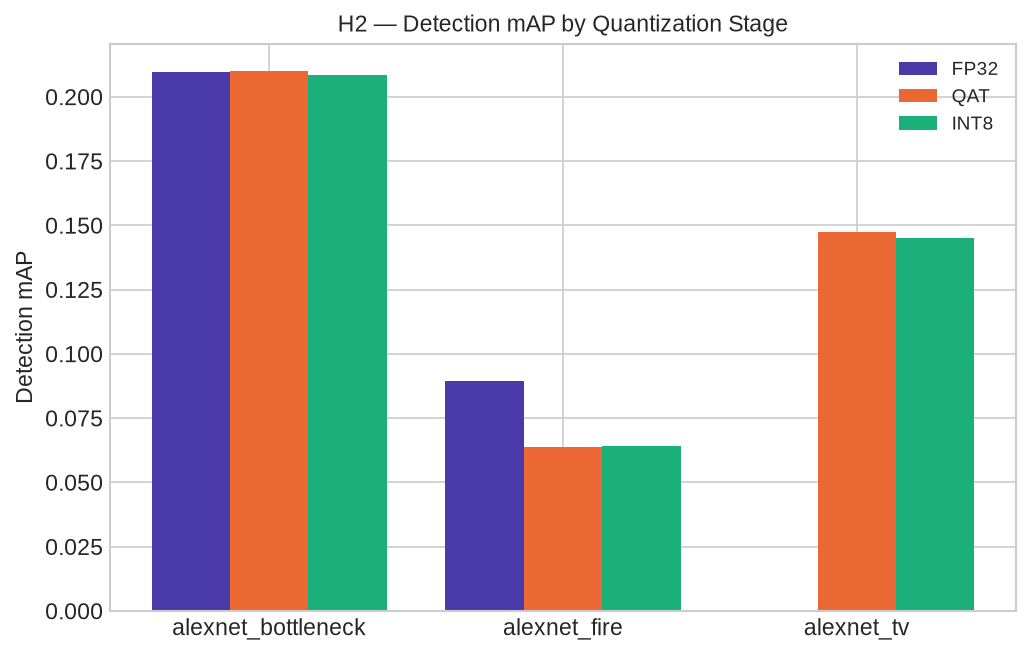


FP32 -> QAT mAP drift (proxy only, not the FP32-vs-INT8 test H2 actually needs):
                    fp32_mAP   qat_mAP  qat_drift
model                                            
alexnet_bottleneck  0.209839  0.210037   0.000198
alexnet_fire        0.089372  0.063761  -0.025610

FP32 -> INT8 mAP drift (H2's actual test):
                    fp32_mAP  int8_mAP  int8_drift
model                                             
alexnet_bottleneck  0.209839  0.208474   -0.001364
alexnet_fire        0.089372  0.064021   -0.025351


In [35]:
STAGE_COLORS = {"fp32": "#4a3aa7", "qat": "#eb6834", "int8": "#1baf7a"}
STAGE_LABELS = {"fp32": "FP32", "qat": "QAT", "int8": "INT8"}

int8_valid = valid_runs(df_runs, stage="int8", pretrained=False)
if int8_valid.empty:
    int8_runs_present = df_runs[(df_runs["stage"] == "int8") & (~df_runs["pretrained"])]
    print("[blocked] No INT8 detection metrics exist yet — INT8 bars will be absent below.")
    print(f"  INT8 run dirs present: {int8_runs_present['run_dir'].tolist() or 'none'}")
    print("  Known cause: job 811101 crashed with 'min tensor(inf) should be less than max "
          "tensor(-inf)' — observer calibration issue in the INT8 convert step, not yet fixed.")

# One Series per stage that currently has >=1 valid run; stages with none simply don't appear
# below, so INT8 shows up automatically once it has real metrics.
stage_mAP = {}
for stage in ("fp32", "qat", "int8"):
    sv = valid_runs(df_runs, stage=stage, pretrained=False)
    if not sv.empty:
        stage_mAP[stage] = sv.set_index("model")["best_val_mAP"]

if not stage_mAP:
    print("[skip] No stage has any valid (post-fix, complete) run — nothing to plot for H2.")
else:
    models_present = sorted(
        set().union(*(s.index for s in stage_mAP.values())), key=MODEL_ORDER.index
    )
    x = np.arange(len(models_present))
    n_stages = len(stage_mAP)
    width = 0.8 / n_stages

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for i, (stage, series) in enumerate(stage_mAP.items()):
        values = [series.get(m, np.nan) for m in models_present]
        offset = (i - (n_stages - 1) / 2) * width
        ax.bar(x + offset, values, width, label=STAGE_LABELS[stage], color=STAGE_COLORS[stage])
    ax.set_xticks(x)
    ax.set_xticklabels(models_present)
    ax.set_ylabel("Detection mAP")
    ax.set_title("H2 — Detection mAP by Quantization Stage")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase7_h2_quantization_stages.png", dpi=150)
    plt.show()

    if "fp32" in stage_mAP and "qat" in stage_mAP:
        h2_df = stage_mAP["fp32"].rename("fp32_mAP").to_frame().join(
            stage_mAP["qat"].rename("qat_mAP"), how="inner"
        )
        h2_df["qat_drift"] = h2_df["qat_mAP"] - h2_df["fp32_mAP"]
        print("\nFP32 -> QAT mAP drift (proxy only, not the FP32-vs-INT8 test H2 actually needs):")
        print(h2_df.to_string())

    if "fp32" in stage_mAP and "int8" in stage_mAP:
        h2_int8_df = stage_mAP["fp32"].rename("fp32_mAP").to_frame().join(
            stage_mAP["int8"].rename("int8_mAP"), how="inner"
        )
        h2_int8_df["int8_drift"] = h2_int8_df["int8_mAP"] - h2_int8_df["fp32_mAP"]
        print("\nFP32 -> INT8 mAP drift (H2's actual test):")
        print(h2_int8_df.to_string())

## H3 — Is dense prediction more receptive-field-sensitive than classification?

For each backbone, detection mAP is expressed relative to that backbone's *own* classification
top-1 (not normalized across backbones as in H1) — this isolates whether a backbone is
disproportionately worse at localization than it is at classification, independent of its overall
strength.

             model  fp32_top1  best_val_mAP  mAP_per_top1
alexnet_bottleneck  44.622979      0.209839      0.470248
      alexnet_fire  43.976474      0.089372      0.203226


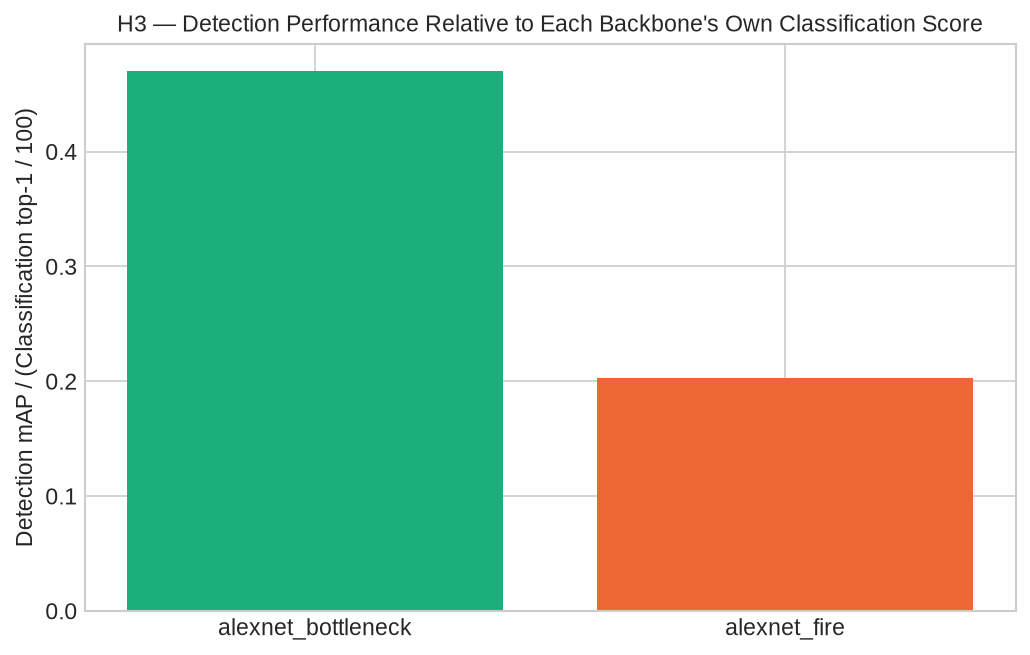

In [36]:
fp32_valid = valid_runs(df_runs, stage="fp32", pretrained=False)

if phase3_df.empty or fp32_valid.empty:
    print("[skip] Same data dependency as H1.")
else:
    h3_df = fp32_valid.merge(
        phase3_df[["arch", "fp32_top1"]], left_on="model", right_on="arch", how="inner"
    )[["model", "fp32_top1", "best_val_mAP"]]
    h3_df["mAP_per_top1"] = h3_df["best_val_mAP"] / (h3_df["fp32_top1"] / 100.0)
    print(h3_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    colors = [MODEL_COLORS[m] for m in h3_df["model"]]
    ax.bar(h3_df["model"], h3_df["mAP_per_top1"], color=colors)
    ax.set_ylabel("Detection mAP / (Classification top-1 / 100)")
    ax.set_title("H3 — Detection Performance Relative to Each Backbone's Own Classification Score")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase7_h3_rf_sensitivity.png", dpi=150)
    plt.show()

## H4 — Does the detection head dominate latency, reintroducing Winograd-irrelevant structure?

Per `ideas/PHASE7_PLAN.md` Task 9: reuse Phase 6's profiling utilities directly, no new profiling
code. `RUN_PROFILING` defaults to `False` — this is the only cell in the notebook that would build
and run a model, and it must never execute on the PCAD front-end (see `pcad_frontend_restriction`
in project memory). With it off, the cell falls back to each run's own recorded
`latency_ms_per_image` (already measured once per training run, no re-profiling needed) alongside
Phase 6's backbone-only latency numbers for comparison.

Recorded full-model (backbone + SSD head, 512x512 VOC input) latency, from each run's own metrics.json:
             model  latency_ms_per_image  params_m         macs  model_size_mb
alexnet_bottleneck              8.025433  1.532362 4.465787e+09       5.964869
      alexnet_fire             10.781682  1.663514 1.911934e+10       6.462511

CAVEAT: Phase 6 latency is backbone-only @ 64x64 (classification); Phase 7 is backbone+SSD head @ 512x512 (detection) -- a 64x larger input area. The ratio below reflects both effects combined, not the SSD head in isolation:
                    latency_ms_per_image  backbone_only_latency_ms      ratio
model                                                                        
alexnet_bottleneck              8.025433                  0.813168   9.869339
alexnet_fire                   10.781682                  0.850081  12.683117


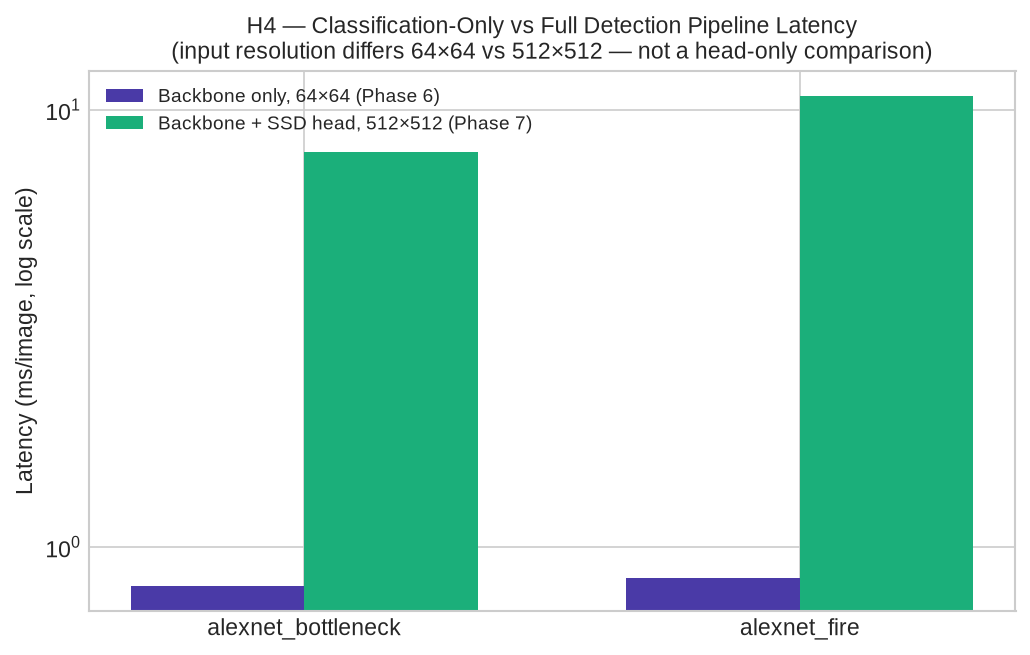

In [37]:
RUN_PROFILING = False  # set True only on a machine with a GPU available for interactive use

fp32_valid_h4 = valid_runs(df_runs, stage="fp32", pretrained=False)
phase6_latency_path = PROJECT_ROOT / "results" / "phase_6_hardware_profiling_analysis" / "h3_latency_pareto.csv"
phase6_latency = pd.read_csv(phase6_latency_path) if phase6_latency_path.exists() else pd.DataFrame()

if fp32_valid_h4.empty:
    print("[skip] No valid FP32 runs with recorded latency yet.")
else:
    print("Recorded full-model (backbone + SSD head, 512x512 VOC input) latency, from each run's own metrics.json:")
    print(fp32_valid_h4[["model", "latency_ms_per_image", "params_m", "macs", "model_size_mb"]].to_string(index=False))

    if phase6_latency.empty:
        print("\n[skip] Phase 6 latency file not found — can't compare against backbone-only numbers.")
    elif "model" not in phase6_latency.columns:
        print(f"\n[skip] {phase6_latency_path.name} has no 'model' column — schema changed, check manually.")
    else:
        backbone_only = phase6_latency[phase6_latency["precision"] == "fp32"].set_index("model")["latency_ms"]
        h4_df = fp32_valid_h4.set_index("model")[["latency_ms_per_image"]].join(
            backbone_only.rename("backbone_only_latency_ms"), how="inner"
        )
        if h4_df.empty:
            print("\n[skip] No model overlap between Phase 6 and Phase 7 latency tables.")
        else:
            # Phase 6 times the backbone ALONE on 64x64 Tiny ImageNet; Phase 7 times backbone+SSD
            # head on 512x512 VOC input (configs/detection.yaml's img_size, confirmed against each
            # run's own saved config.yaml). The gap below is therefore driven by BOTH the added
            # head AND a 64x larger input area — it does not isolate head-only cost.
            h4_df["ratio"] = h4_df["latency_ms_per_image"] / h4_df["backbone_only_latency_ms"]
            print("\nCAVEAT: Phase 6 latency is backbone-only @ 64x64 (classification); Phase 7 is "
                  "backbone+SSD head @ 512x512 (detection) -- a 64x larger input area. The ratio "
                  "below reflects both effects combined, not the SSD head in isolation:")
            print(h4_df.to_string())

            models_present = [m for m in MODEL_ORDER if m in h4_df.index]
            x = np.arange(len(models_present))
            width = 0.35

            fig, ax = plt.subplots(figsize=(7, 4.5))
            ax.bar(x - width / 2, h4_df.loc[models_present, "backbone_only_latency_ms"], width,
                   label="Backbone only, 64×64 (Phase 6)", color="#4a3aa7")
            ax.bar(x + width / 2, h4_df.loc[models_present, "latency_ms_per_image"], width,
                   label="Backbone + SSD head, 512×512 (Phase 7)", color="#1baf7a")
            ax.set_xticks(x)
            ax.set_xticklabels(models_present)
            ax.set_ylabel("Latency (ms/image, log scale)")
            ax.set_yscale("log")
            ax.set_title("H4 — Classification-Only vs Full Detection Pipeline Latency\n(input resolution differs 64×64 vs 512×512 — not a head-only comparison)")
            ax.legend()
            fig.tight_layout()
            fig.savefig(FIGURES_DIR / "phase7_h4_latency_stages.png", dpi=150)
            plt.show()

## Accuracy vs. Model Size — FP32 / QAT / INT8

QAT and INT8 are *not* the same artifact. **QAT** (quantization-aware training) still stores
weights as FP32 — it inserts fake-quant/observer ops so the forward pass *simulates* 8-bit
rounding during training so the weights learn to tolerate it, which is why the `qat` points below
are the same size as `fp32`, not smaller (observer buffers even push it slightly larger). **INT8**
is the actual post-training conversion (`convert_ssd_to_int8`, CPU-only per this project's
convention) that repacks the QAT-trained weights into real 8-bit tensors — that's where the size
drop and the CPU-only inference happen. QAT is the training recipe; INT8 is the deployed artifact.

`scripts/train_det_seg.py`'s `int8` branch didn't record that size (only `fp32`/`qat` called
`compute_detection_summary()`) — now fixed for future runs, and existing runs were backfilled by
rebuilding each INT8 model from its QAT checkpoint and measuring the real saved `.pth`
(`scripts/backfill_int8_size.py`), not estimated.

The real numbers overturn a naive assumption: INT8 is **not** ~4x smaller than FP32 here.
`build_qat_ssd_detector` only quantizes the backbone — the SSD head's classification/regression
convs stay FP32 by design (see its docstring). So the real reduction is architecture-dependent:
bottleneck/fire shrink only ~1.8x (their backbones are most of the param count), while
`alexnet_tv`'s checkpoint barely shrinks at all (<1%) — its backbone is a small fraction of its
58M params, dominated by a large FC-based classifier that stays FP32. Any model still missing a
real INT8 size (not yet re-run, or its QAT checkpoint is stale — see backfill script's skip
messages) falls back to the same theoretical estimate as before, shown hollow to distinguish it
from measured points.

/tmp/ipykernel_491009/2629015968.py:71: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_491009/2629015968.py:72: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Liberation Sans.
  fig.savefig(FIGURES_DIR / "phase7_accuracy_vs_size.png", dpi=150)
/home/rafael/Documents/dnn_study/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9651 (\N{WHITE UP-POINTING TRIANGLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


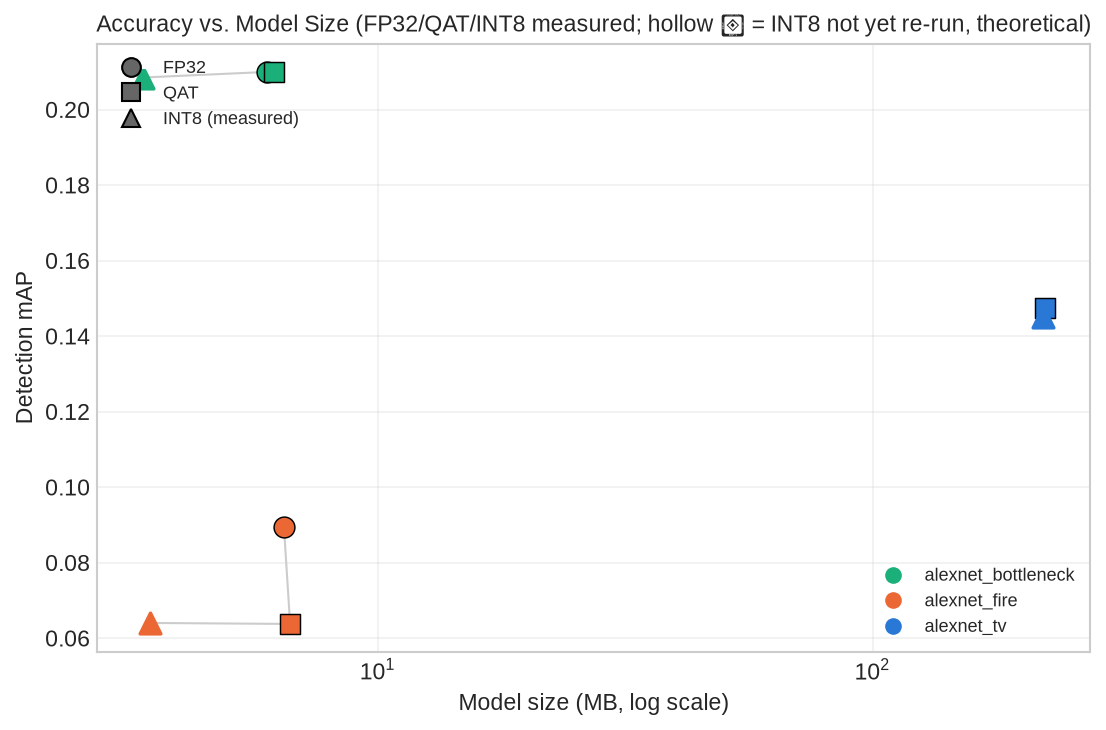

             model stage  model_size_mb  best_val_mAP
alexnet_bottleneck  fp32       5.964869      0.209839
alexnet_bottleneck   qat       6.158990      0.210037
      alexnet_fire  fp32       6.462511      0.089372
      alexnet_fire   qat       6.650516      0.063761
        alexnet_tv   qat     223.505725      0.147321

INT8 (measured where available):
             model  model_size_mb  best_val_mAP
alexnet_bottleneck       3.347330      0.208474
      alexnet_fire       3.466467      0.064021
        alexnet_tv     221.544245      0.145015


In [38]:
size_stages = df_runs[(df_runs["status"] == "complete") & (df_runs["post_fix"] == True) & (~df_runs["pretrained"])]
fp32_qat = size_stages[size_stages["stage"].isin(["fp32", "qat"])]
int8_acc = size_stages[size_stages["stage"] == "int8"]
params_by_model = fp32_qat.dropna(subset=["params_m"]).drop_duplicates("model").set_index("model")["params_m"]

if fp32_qat.empty:
    print("[skip] No valid FP32/QAT runs with recorded size yet.")
else:
    STAGE_MARKERS = {"fp32": "o", "qat": "s"}
    fig, ax = plt.subplots(figsize=(7.5, 5))

    def int8_point(row):
        """(size_mb, is_measured) -- real measured size if scripts/backfill_int8_size.py (or
        the now-fixed training script) filled it in, else the old theoretical estimate."""
        if pd.notna(row["model_size_mb"]):
            return row["model_size_mb"], True
        if row["model"] in params_by_model.index:
            return params_by_model[row["model"]] * 1e6 / (1024 ** 2), False
        return None, None

    # fp32 -> qat -> int8 connector per model, same gray-line visual language as
    # report/generate_figures.py's accuracy-vs-size Pareto figure. Any stage missing for a model
    # (e.g. alexnet_tv's still-invalid pre-fix fp32) is simply skipped, not fabricated.
    for model in MODEL_ORDER:
        pts = [(r["model_size_mb"], r["best_val_mAP"])
               for _, r in fp32_qat[fp32_qat["model"] == model].sort_values("stage").iterrows()]
        int8_row = int8_acc[int8_acc["model"] == model]
        if not int8_row.empty:
            size_mb, _ = int8_point(int8_row.iloc[0])
            if size_mb is not None:
                pts.append((size_mb, int8_row.iloc[0]["best_val_mAP"]))
        if len(pts) >= 2:
            xs, ys = zip(*pts)
            ax.plot(xs, ys, color="0.8", linewidth=1, zorder=1)

    for _, row in fp32_qat.iterrows():
        ax.scatter(row["model_size_mb"], row["best_val_mAP"], s=100,
                   marker=STAGE_MARKERS[row["stage"]], color=MODEL_COLORS[row["model"]],
                   edgecolor="black", linewidth=0.7, zorder=3)

    any_estimated = False
    for _, row in int8_acc.iterrows():
        size_mb, measured = int8_point(row)
        if size_mb is None:
            continue
        any_estimated = any_estimated or not measured
        ax.scatter(size_mb, row["best_val_mAP"], s=100, marker="^",
                   facecolor=MODEL_COLORS[row["model"]] if measured else "none",
                   edgecolor=MODEL_COLORS[row["model"]], linewidth=1.6, zorder=3)

    ax.set_xscale("log")
    ax.set_xlabel("Model size (MB, log scale)")
    ax.set_ylabel("Detection mAP")
    ax.set_title("Accuracy vs. Model Size (FP32/QAT/INT8 measured; hollow △ = INT8 not yet re-run, theoretical)")

    stage_legend = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="0.4", markeredgecolor="black", markersize=9, label="FP32"),
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="0.4", markeredgecolor="black", markersize=9, label="QAT"),
        plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="0.4", markeredgecolor="black", markersize=9, label="INT8 (measured)"),
    ]
    if any_estimated:
        stage_legend.append(plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="none",
                                        markeredgecolor="0.4", markersize=9, label="INT8 (theoretical, not yet measured)"))
    model_legend = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=m)
                     for m, c in MODEL_COLORS.items()]
    leg1 = ax.legend(handles=stage_legend, loc="upper left", fontsize=8.5, frameon=False)
    ax.legend(handles=model_legend, loc="lower right", fontsize=8.5, frameon=False)
    ax.add_artist(leg1)
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase7_accuracy_vs_size.png", dpi=150)
    plt.show()

    print(fp32_qat[["model", "stage", "model_size_mb", "best_val_mAP"]].sort_values(["model", "stage"]).to_string(index=False))
    print("\nINT8 (measured where available):")
    print(int8_acc[["model", "model_size_mb", "best_val_mAP"]].sort_values("model").to_string(index=False))

## Segmentation Status (Part B — unstarted)

`create_voc_segmentation_loaders()` exists, but `build_deeplabv3_segmenter()` is a hardcoded
placeholder ignoring this project's own backbones, `SegmentationTrainer.fit()` is a one-line stub,
and `run_segmentation()` in `scripts/train_det_seg.py` prints "not yet implemented". B1–B7
(real DeepLabV3 head → QAT/INT8 → real trainer → CLI → reporting → cross-phase analysis extension
→ PCAD runs) all remain — deferred until detection (Part A) results are trusted end-to-end.

## Conclusions & Persist

In [39]:
if not df_runs.empty:
    export_path = RESULTS_DIR / "phase7_comparison.csv"
    df_runs.to_csv(export_path, index=False)
    print(f"Exported {len(df_runs)} rows -> {export_path}")
else:
    print("[skip] No runs to export.")

print("""
Limitations (n as of this writing, 2026-08-13, after a PCAD resync):
- alexnet_bottleneck and alexnet_fire now both have valid (post-fix, completed) FP32/QAT/INT8
  runs, pretrained and non-pretrained. alexnet_tv's non-pretrained FP32 is still the stale
  pre-fix run (its rerun is in flight on PCAD); tv_fp32_pretrained is running; tv_qat_pretrained
  and tv_int8_pretrained haven't started (queued behind it). H1 needs tv_fp32 specifically as its
  normalization reference and will stay blocked until that lands — re-run this notebook once it
  does to fill in H1/H3 for all three backbones.
- H2/H4 (quantization and latency) are effectively unblocked for bottleneck/fire — only tv's
  FP32/QAT/INT8-pretrained variants remain outstanding.
- H4's comparison against Phase 6 latency mixes two effects: Phase 6 measures the backbone alone
  on 64x64 classification input, Phase 7 measures backbone+SSD head on 512x512 detection input
  (configs/detection.yaml). Read the gap as "full pipeline vs classification-only", not as
  isolated SSD-head overhead.
- INT8 model size is now real for 5 of 6 completed INT8 runs (backfilled via
  scripts/backfill_int8_size.py from each QAT checkpoint; scripts/train_det_seg.py's int8 branch
  now records it directly for future runs). The measured reduction is much smaller than a naive
  4x: build_qat_ssd_detector only quantizes the backbone, so bottleneck/fire shrink ~1.8x and
  alexnet_tv (FC-classifier-dominated) barely shrinks at all.
- Any correlation statistic (Spearman rho) computed here is on n<=3 and has essentially no
  statistical power -- read as descriptive, not evidence.
- alexnet_tv's anchor recall (0.932) sits below the 0.95 target; accepted as a residual gap from
  its structurally coarser native feature pyramid, not chased further (ideas/PHASE7_PLAN.md
  Stage 9 log) -- alexnet_tv detection runs use --skip-anchor-check.
- Segmentation (Part B) contributes nothing to this notebook -- see status above.
""")

Exported 16 rows -> /home/rafael/Documents/dnn_study/results/phase_7_detection_segmentation_analysis/phase7_comparison.csv

Limitations (n as of this writing, 2026-08-13, after a PCAD resync):
- alexnet_bottleneck and alexnet_fire now both have valid (post-fix, completed) FP32/QAT/INT8
  runs, pretrained and non-pretrained. alexnet_tv's non-pretrained FP32 is still the stale
  pre-fix run (its rerun is in flight on PCAD); tv_fp32_pretrained is running; tv_qat_pretrained
  and tv_int8_pretrained haven't started (queued behind it). H1 needs tv_fp32 specifically as its
  normalization reference and will stay blocked until that lands — re-run this notebook once it
  does to fill in H1/H3 for all three backbones.
- H2/H4 (quantization and latency) are effectively unblocked for bottleneck/fire — only tv's
  FP32/QAT/INT8-pretrained variants remain outstanding.
- H4's comparison against Phase 6 latency mixes two effects: Phase 6 measures the backbone alone
  on 64x64 classification input, Pha